In [10]:
import os 
os.chdir('/root/autolabeling_time_series_data/')

from src.feature_extraction import ts2vec_load_data, ts2vec_infer
from src.utils import plot_series, prepare_to_ts2vec

In [53]:
# prepare_to_ts2vec('ItalyPowerDemand')
# import pandas as pd 

# file = pd.read_csv('src/feature_extraction/ts2vec/datasets/UCR/ItalyPowerDemand/ItalyPowerDemand_TRAIN.tsv', sep='\t', header=None)
# file

In [66]:
# from aeon.datasets import load_classification

# X, y = load_classification('ItalyPowerDemand')

In [124]:
import numpy as np
import pandas as pd

data = np.load('data/UCR_benchmark/datasets/BasicMotions/raw_features.npy')
lbl = pd.read_csv('data/UCR_benchmark/datasets/BasicMotions/labels.csv').values.reshape(-1,)
data[0], lbl[0]

(array([[ 7.910600e-02,  7.910600e-02, -9.034970e-01,  1.116125e+00,
          1.638200e+00,  1.003448e+00,  2.877400e-02,  3.005000e-02,
         -1.204850e-01, -1.204850e-01,  6.674960e-01, -3.128150e-01,
         -3.206400e-02,  4.626540e-01,  4.626540e-01,  5.072600e-01,
          3.817740e-01, -1.731090e-01,  7.556600e-02,  1.826020e-01,
          2.413390e-01,  1.288280e-01, -5.551000e-03, -2.343810e-01,
         -6.006100e-02,  1.343050e-01, -1.192170e-01, -1.184150e-01,
         -3.485700e-02, -1.527360e-01, -3.027500e-01, -2.582840e-01,
         -1.530460e-01, -1.839760e-01, -1.609710e-01, -2.415540e-01,
         -1.260500e-01, -4.755800e-02, -1.806560e-01, -2.233210e-01,
         -2.695440e-01, -1.322180e-01, -2.475980e-01, -1.671510e-01,
         -2.267870e-01, -2.267870e-01, -2.211940e-01, -1.245250e-01,
         -2.153840e-01, -2.923420e-01, -2.096000e-01, -3.502830e-01,
         -2.123050e-01, -1.019160e-01, -1.254740e-01, -1.713080e-01,
         -3.927370e-01, -3.337020e

In [126]:
data.shape

(80, 6, 100)

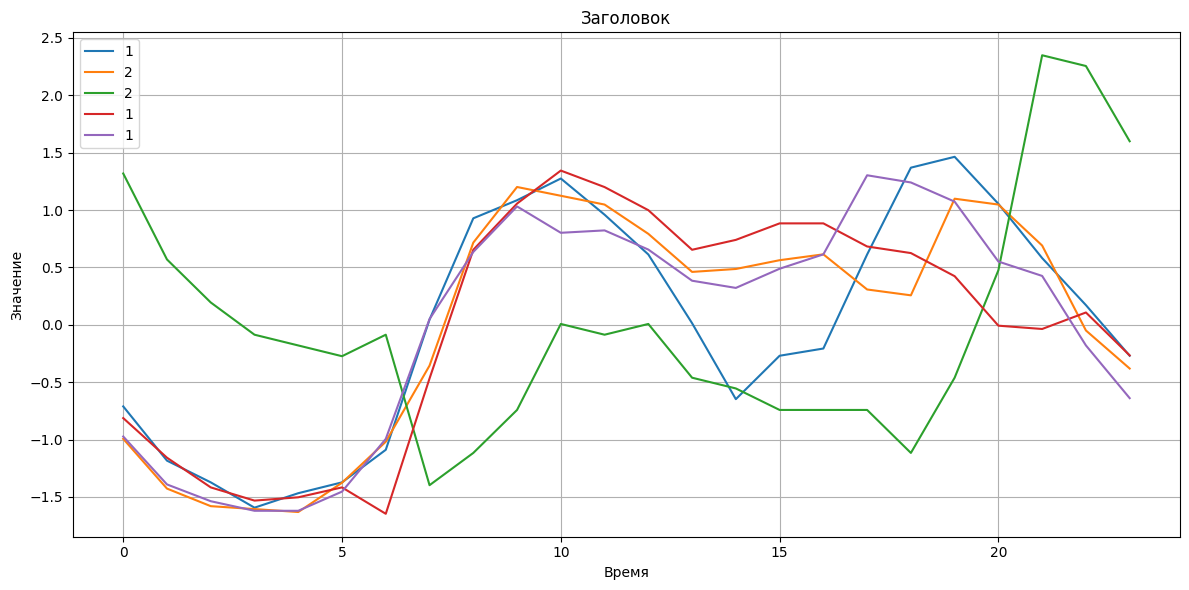

In [91]:
plot_series(data[:5, 0, :].T, labels=lbl[:5].tolist())

In [ ]:
train_data, train_labels, test_data, test_labels = ts2vec_load_data('')

Data is not numeric, LabelEncoder is used
Old Classes: ['badminton' 'running' 'standing' 'walking']
New Classes: [0 1 2 3]


ValueError: cannot select an axis to squeeze out which has size not equal to one

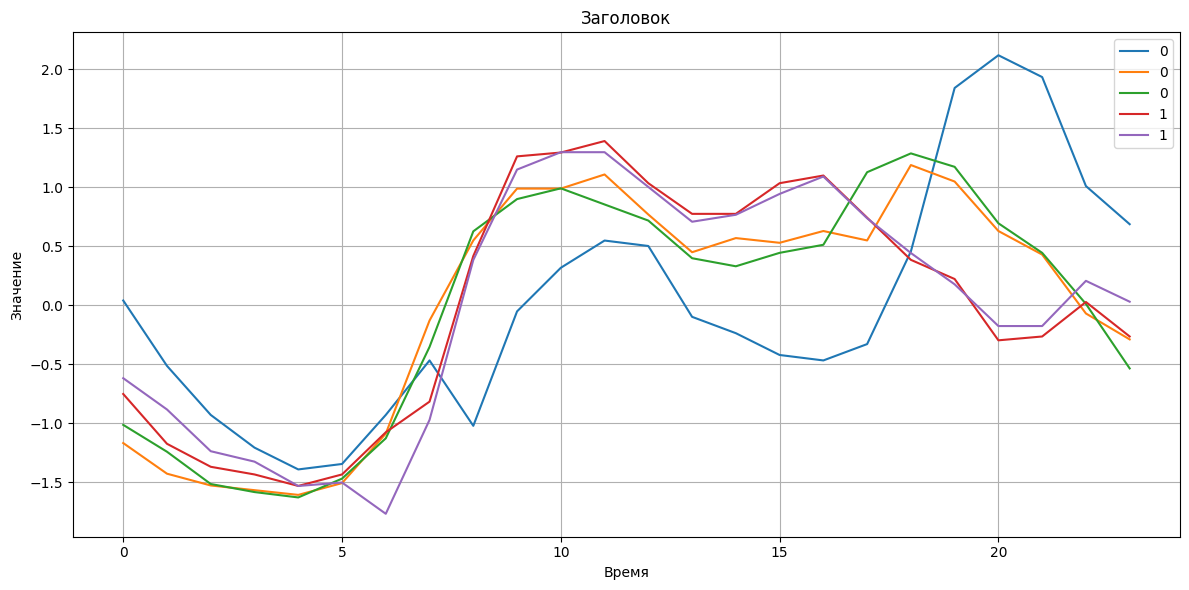

In [123]:
plot_series(test_data[:5, :, 0].T, labels=test_labels[:5].tolist())

# cls1_mask = test_labels == 0
# cls2_mask = test_labels == 1

# plot_series(test_data[cls1_mask, :, 0].T, labels=test_labels[cls1_mask].tolist())
# plot_series(test_data[cls2_mask, :, 0].T, labels=test_labels[cls2_mask].tolist())

# Eval (ItalyPowerDemand)

In [172]:
from pathlib import Path
import pandas as pd 
import numpy as np

In [208]:
full_df = pd.DataFrame()

total_path = Path('experiments/FE_with_ts2vec_Chinatown/ts2vec_config1/res')
# Path('experiments/FE_with_ts2vec_EthanolLevel/ts2vec_config3/res')
# Path('experiments/FE_with_ts2vec_inc_MelbournePedestrian/ts2vec_config3/res')
# Path('experiments/FE_with_ts2vec_ItalyPowerDemand/ts2vec_config0/res')
# Path('experiments/FE_with_ts2vec_inc_MelbournePedestrian/ts2vec_config0/res')

for filepath in total_path.iterdir():
    new_data = pd.read_excel(filepath)
    new_data['source'] = filepath.parts[-1]
    full_df = pd.concat([full_df, new_data])

full_df = full_df.drop(['Unnamed: 0'], axis=1)
full_df

# Установка глобальной опции отображения для ширины столбца
pd.set_option('display.max_colwidth', 100)

full_df.loc[full_df['metric'] == 'accuracy'].sort_values(['value'], ascending=False).head(20)

,parameter,metric,value,source
360,"{'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 15}",accuracy,0.808219,KMeans_Chinatown_0_8.xlsx
10,"{'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 15}",accuracy,0.808219,KMeans_Chinatown_0_8.xlsx
353,"{'init': 'random', 'max_iter': 300, 'n_clusters': 2, 'n_init': 5}",accuracy,0.808219,KMeans_Chinatown_0_8.xlsx
5330,"{'branching_factor': 90, 'n_clusters': 2, 'threshold': 0.825}",accuracy,0.808219,BIRCH_Chinatown_0_8.xlsx
10,"{'branching_factor': 10, 'n_clusters': 2, 'threshold': 0.825}",accuracy,0.808219,BIRCH_Chinatown_0_8.xlsx
80,"{'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 15}",accuracy,0.808219,KMeans_Chinatown_0_8.xlsx
73,"{'init': 'k-means++', 'max_iter': 200, 'n_clusters': 2, 'n_init': 5}",accuracy,0.808219,KMeans_Chinatown_0_8.xlsx
4665,"{'branching_factor': 80, 'n_clusters': 2, 'threshold': 0.825}",accuracy,0.808219,BIRCH_Chinatown_0_8.xlsx
2005,"{'branching_factor': 40, 'n_clusters': 2, 'threshold': 0.825}",accuracy,0.808219,BIRCH_Chinatown_0_8.xlsx
3335,"{'branching_factor': 60, 'n_clusters': 2, 'threshold': 0.825}",accuracy,0.808219,BIRCH_Chinatown_0_8.xlsx
